# 05 — Extracción de Características
## Pipeline CAD-TBX11K | Diagnóstico Asistido por Computador en Tuberculosis

Este notebook construye la **matriz de características** que servirá como entrada a
los modelos de machine learning. Cada radiografía es convertida en un vector numérico
de **1828 características** agrupadas en cinco grupos.

### Grupos de características

| Grupo                | Qué captura                                            | Features |
|----------------------|--------------------------------------------------------|:--------:|
| Intensidad global    | brillo, variabilidad, rango dinámico, entropía         |     4    |
| Intensidad regional  | las mismas 4 métricas en 6 zonas anatómicas            |    24    |
| GLCM                 | relación entre píxeles vecinos — textura del tejido    |    10    |
| LBP                  | micro-patrones locales — bordes y transiciones         |    26    |
| HOG                  | gradientes orientados — forma y estructura             |  1764    |
| **Total**            |                                                        | **1828** |

### Pipeline por imagen

```
imagen → preprocess() → feat_intensity_global()
                      → feat_intensity_regional()
                      → feat_glcm()
                      → feat_lbp()
                      → feat_hog()
                      → fila del CSV
```



## 0. Configuración del entorno

In [27]:
# Se configura el path del proyecto y se importan las funciones del framework.

import sys, os, warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd

from src.data import download_dataset, get_data_root, build_base_dataframe, LABEL_MAP
from src.features import (
    verify_extractors,        # Verifica el número correcto de features por extractor
    extract_all_features,     # Extracción masiva sobre el DataFrame base
    get_feature_groups,       # Clasifica columnas por grupo de extractor
    print_feature_summary,    # Resumen de integridad del DataFrame de features
    REGIONS, GLCM_PROPS,
    LBP_P, LBP_R, HOG_PIXELS_PER_CELL,
)
from src.visualization import (
    set_publication_style,
    plot_glcm_distributions,
    plot_lbp_histograms,
    plot_feature_summary_table,
)


from pathlib import Path
OUTPUT_CSV = Path('..') / 'data' / 'features_tbx11k.csv'

set_publication_style()
print('Entorno configurado correctamente.')

Entorno configurado correctamente.


## 1. Carga del DataFrame base

In [28]:
# Se carga el DataFrame base desde data/df_base.csv.
# Si aún no existe, ejecutar primero el notebook 01 para generarlo.
from pathlib import Path
CSV_PATH = Path('..') / 'data' / 'df_base.csv'

if CSV_PATH.exists():
    df_base = pd.read_csv(CSV_PATH)
    print(f'DataFrame cargado desde: {CSV_PATH.resolve()}')
    print(f'Total imágenes: {len(df_base)}')
else:
    print(f'[ERROR] No se encontró: {CSV_PATH.resolve()}')
    print('Ejecuta primero el notebook 01 para generar df_base.csv')

print()
print(df_base['class_name'].value_counts())

DataFrame cargado desde: C:\Users\bernarda.salazar\Documents\GitHub\CAD_TBX11K\data\df_base.csv
Total imágenes: 30

class_name
health    10
sick      10
tb        10
Name: count, dtype: int64


## 2. Parámetros de los extractores

In [29]:
# Se muestran los parámetros configurados en `cad_tbx11k/features.py`.
# Modificar estos valores afecta directamente la dimensionalidad y el contenido
# del vector de características resultante.

print('Parámetros de los extractores de características:')
print()
print(f'  GLCM — propiedades calculadas  : {GLCM_PROPS}')
print(f'  GLCM — ángulos (rad)           : [0, π/4, π/2, 3π/4]')
print(f'  GLCM — niveles de gris         : 64 (img // 4)')
print()
print(f'  LBP — puntos de muestreo (P)   : {LBP_P}')
print(f'  LBP — radio (R)                : {LBP_R}')
print(f'  LBP — método                   : uniform')
print(f'  LBP — bins del histograma      : {LBP_P + 2}')
print()
print(f'  HOG — orientaciones            : 9')
print(f'  HOG — píxeles por celda        : {HOG_PIXELS_PER_CELL}')
print(f'  HOG — celdas por bloque        : (2, 2)')
print(f'  HOG — normalización de bloque  : L2-Hys')
print()
print(f'  Regiones anatómicas            : {list(REGIONS.keys())}')

Parámetros de los extractores de características:

  GLCM — propiedades calculadas  : ['contrast', 'correlation', 'energy', 'homogeneity', 'dissimilarity']
  GLCM — ángulos (rad)           : [0, π/4, π/2, 3π/4]
  GLCM — niveles de gris         : 64 (img // 4)

  LBP — puntos de muestreo (P)   : 24
  LBP — radio (R)                : 3.0
  LBP — método                   : uniform
  LBP — bins del histograma      : 26

  HOG — orientaciones            : 9
  HOG — píxeles por celda        : (32, 32)
  HOG — celdas por bloque        : (2, 2)
  HOG — normalización de bloque  : L2-Hys

  Regiones anatómicas            : ['SI', 'SD', 'MI', 'MD', 'II', 'ID']


## 3. Verificación de los extractores

In [30]:
# Se verifica que cada extractor produce el número correcto de features
# sobre una imagen de muestra de cada clase antes de procesar el dataset completo.
# Esto detecta errores de configuración de forma temprana y económica.
# Se ejecutan assertions que fallan con mensaje claro si hay una discrepancia.

verify_extractors(df_base)

health | global=4  regional=24  GLCM=10  LBP=26  HOG=1764  TOTAL=1828
  sick | global=4  regional=24  GLCM=10  LBP=26  HOG=1764  TOTAL=1828
    tb | global=4  regional=24  GLCM=10  LBP=26  HOG=1764  TOTAL=1828

Esperado: global=4  regional=24  GLCM=10  LBP=26  HOG=1764  TOTAL=1828
Verificación completada sin errores.


## 4. Extracción masiva de características

In [31]:
# Se verifica que df_base tiene las columnas necesarias para la extracción.
# Si se cargó desde CSV, se reconstruyen label y class_name si faltan.

from pathlib import Path
from src.data import LABEL_MAP

if 'label' not in df_base.columns:
    df_base['label'] = df_base['class_name'].map(LABEL_MAP)

if 'class_name' not in df_base.columns:
    df_base['class_name'] = df_base['image_path'].apply(lambda p: Path(p).parent.name)
    df_base = df_base[df_base['class_name'].isin(LABEL_MAP)].reset_index(drop=True)
    df_base['label'] = df_base['class_name'].map(LABEL_MAP)

print(df_base.columns.tolist())
print(df_base['class_name'].value_counts())

['image_path', 'class_name', 'label', 'ancho', 'alto', 'modo']
class_name
health    10
sick      10
tb        10
Name: count, dtype: int64


In [32]:
# Se procesan las imágenes del dataset.
# sample=True usa N_POR_CLASE imágenes por clase para pruebas rápidas.
# Cambiar a sample=False para procesar el dataset completo.

N_POR_CLASE = df_base['class_name'].value_counts().min()

features_df, errores = extract_all_features(
    df_base,
    sample=True,          # cambiar a False para el dataset completo
    sample_size=N_POR_CLASE,
    random_state=42,
)

if errores:
    print(f'\nImages with read errors ({len(errores)}):')
    for e in errores[:5]:
        print(f'  {e}')

Modo muestra: 30 imágenes (10 por clase).


Extrayendo características: 100%|██████████| 30/30 [00:01<00:00, 25.18it/s]


Procesadas : 30
Errores    : 0
Shape      : (30, 1831)


## 5. Verificación de integridad del DataFrame de características

In [33]:
# Se verifica que el DataFrame resultante está libre de valores nulos e infinitos,
# y que la distribución de clases es la esperada.
# Los valores nulos o infinitos en el vector de features pueden causar fallos
# silenciosos en los modelos de machine learning.

print_feature_summary(features_df)

Filas......................... 30
Features...................... 1828

Distribución de clases:
class_name
health    10
sick      10
tb        10

Valores nulos................. 0
Valores infinitos............. 0

Features por grupo:
  Intensidad global...........     4
  Intensidad regional.........    24
  GLCM........................    10
  LBP.........................    26
  HOG.........................  1764
  TOTAL.......................  1828


In [34]:
# Se muestra la tabla de features por grupo para confirmar la dimensionalidad
# esperada de cada extractor.

tabla_grupos = plot_feature_summary_table(features_df)
print('Resumen de características por grupo:')
print(tabla_grupos.to_string())

Resumen de características por grupo:
                     Features
Group                        
Intensidad global           4
Intensidad regional        24
GLCM                       10
LBP                        26
HOG                      1764
TOTAL                    1828


## 6. Visualización de características GLCM

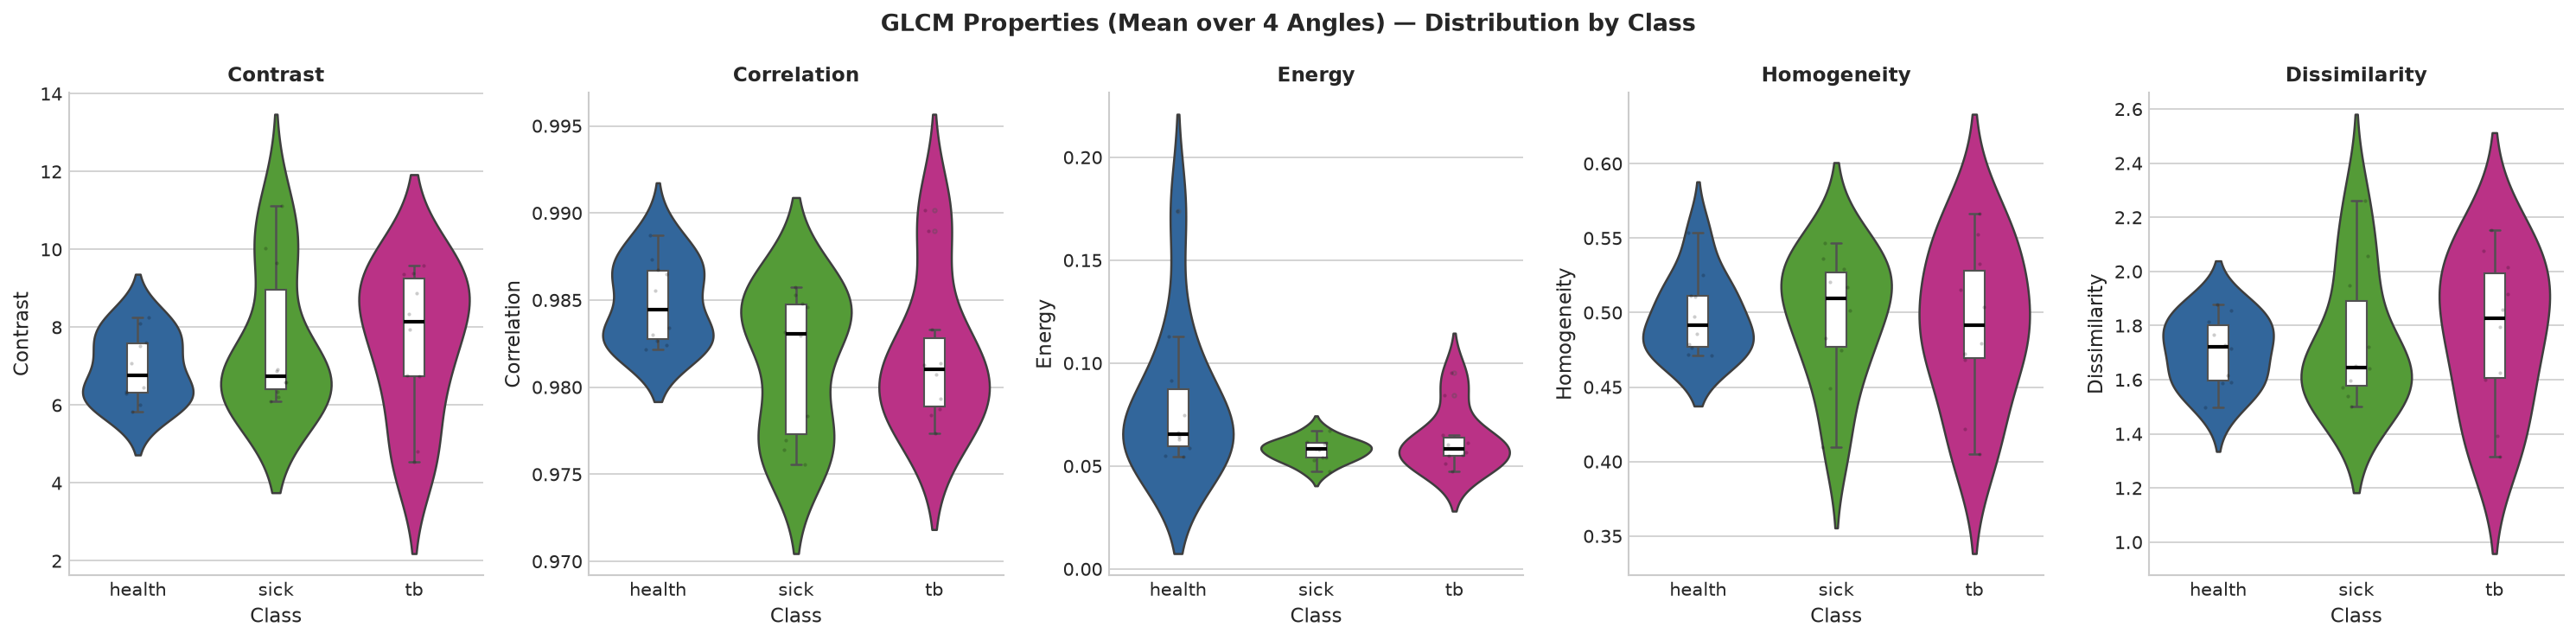

In [35]:
# Se visualizan las distribuciones de las cinco propiedades GLCM por clase.
# Si una propiedad presenta separación visual entre clases, tendrá mayor
# capacidad discriminativa en el modelo de clasificación.
# Referencia graycoprops: https://scikit-image.org/docs/stable/api/skimage.feature.html#skimage.feature.graycoprops

plot_glcm_distributions(features_df)

## 7. Visualización del histograma LBP promedio

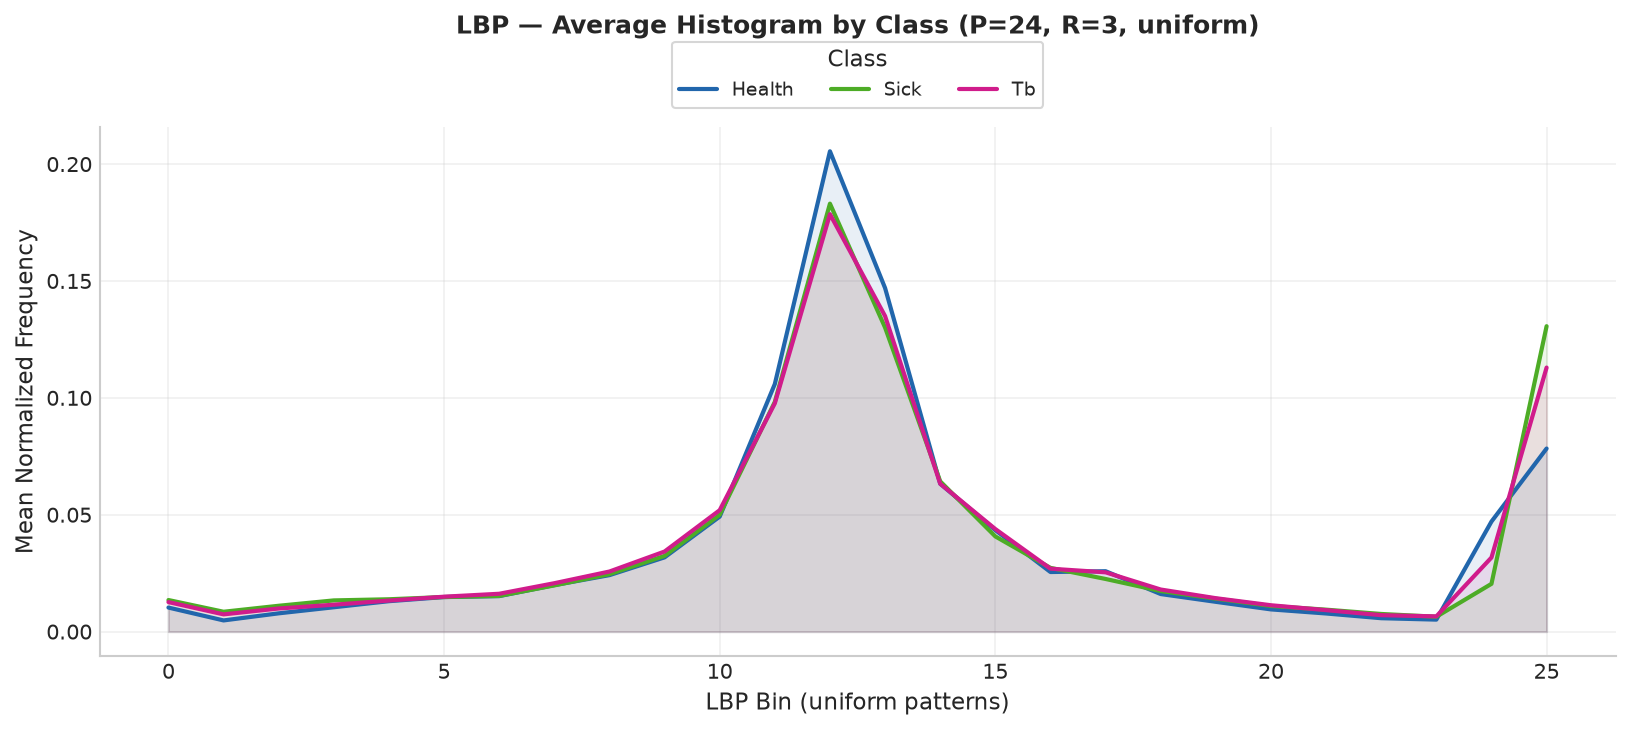

In [36]:
# Se grafica el histograma LBP promedio por clase.
# Diferencias en la distribución de bins LBP indican que las texturas locales
# difieren entre clases, lo cual es útil para la clasificación.


plot_lbp_histograms(features_df)

## 8. Estadísticas descriptivas de las features globales

In [37]:
# Se generan tablas descriptivas de las features de intensidad global por clase.
# Sirven como línea base para interpretar los resultados del modelo de clasificación.

grupos = get_feature_groups(features_df)
glob_cols = grupos['Intensidad global']

# --- Tabla 1: media por clase ---
tabla_mean = (features_df.groupby('class_name')[glob_cols].mean().round(4))
tabla_mean.index.name = 'Class'
print('Table 1 — Mean by class:')
print(tabla_mean.to_string())
print()

# --- Tabla 2: desviación estándar por clase ---
tabla_std = (features_df.groupby('class_name')[glob_cols].std().round(4))
tabla_std.index.name = 'Class'
print('Table 2 — Standard deviation by class:')
print(tabla_std.to_string())
print()

# --- Tabla 3: media ± std consolidada ---
tabla_resumen = tabla_mean.copy().astype(str)
for col in glob_cols:
    tabla_resumen[col] = tabla_mean[col].round(3).astype(str) + ' ± ' + tabla_std[col].round(3).astype(str)
tabla_resumen.index.name = 'Class'
print('Table 3 — Summary (mean ± std):')
print(tabla_resumen.to_string())

Table 1 — Mean by class:
            mean      std  contrast  entropy
Class                                       
health  123.1299  60.8828     254.9   5.3319
sick    133.1715  57.4913     254.9   5.4063
tb      128.2051  58.4917     254.9   5.3825

Table 2 — Standard deviation by class:
          mean     std  contrast  entropy
Class                                    
health  6.1386  1.8677    0.3162   0.1151
sick    4.2031  2.8536    0.3162   0.0424
tb      3.6472  2.6409    0.3162   0.0582

Table 3 — Summary (mean ± std):
                   mean             std       contrast        entropy
Class                                                                
health   123.13 ± 6.139  60.883 ± 1.868  254.9 ± 0.316  5.332 ± 0.115
sick    133.172 ± 4.203  57.491 ± 2.854  254.9 ± 0.316  5.406 ± 0.042
tb      128.205 ± 3.647  58.492 ± 2.641  254.9 ± 0.316  5.382 ± 0.058


## 9. Exportación a CSV

In [38]:
# Se reordena el DataFrame para que las columnas de metadatos queden primero
# y se exporta a CSV en la raíz del proyecto.
# Este archivo es la entrada para la siguiente etapa del pipeline (modelado ML).

meta_cols = ['image_path', 'class_name', 'label']
feat_cols = [c for c in features_df.columns if c not in meta_cols]

features_df = features_df[meta_cols + feat_cols]
features_df.to_csv(OUTPUT_CSV, index=False)

print(f'Guardado en : {OUTPUT_CSV}')
print(f'Shape       : {features_df.shape}')
print(f'Tamaño      : {os.path.getsize(OUTPUT_CSV) / 1024 / 1024:.2f} MB')
print()
print('Primeras 3 filas (columnas de metadatos + primeras 5 features):')
print(features_df[meta_cols + feat_cols[:5]].head(3).to_string(index=False))

Guardado en : ..\data\features_tbx11k.csv
Shape       : (30, 1831)
Tamaño      : 1.04 MB

Primeras 3 filas (columnas de metadatos + primeras 5 features):
                                                                             image_path class_name  label       mean       std  contrast  entropy    SI_mean
C:\Users\bernarda.salazar\Documents\GitHub\CAD_TBX11K\data\TBX11K\imgs\health\h2974.png     health      0 126.619797 59.890655     255.0 5.410147 126.117460
C:\Users\bernarda.salazar\Documents\GitHub\CAD_TBX11K\data\TBX11K\imgs\health\h0778.png     health      0 128.457336 60.926803     255.0 5.436129 125.642896
C:\Users\bernarda.salazar\Documents\GitHub\CAD_TBX11K\data\TBX11K\imgs\health\h1661.png     health      0 123.620407 59.959835     254.0 5.357583 120.145712


## Conclusiones

Los resultados indican que las métricas globales de intensidad capturan algunas diferencias entre clases, especialmente en el brillo promedio de las imágenes. Sin embargo, el elevado solapamiento observado en contraste y entropía sugiere que estas características son insuficientes para separar claramente las categorías. Por ello, resulta necesario complementar este análisis con descriptores de textura, capaces de capturar patrones espaciales más complejos presentes en las imágenes.

## Próximas etapas del proyecto

```
features_tbx11k.csv
       │
       ▼
Análisis de características (correlación, importancia)
       │
       ▼
Reducción de dimensionalidad (PCA, selección de features)
       │
       ▼
Entrenamiento de modelos de clasificación
       │
       ▼
Evaluación del desempeño (ROC, AUC, F1 por clase)
```
